###  Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


###  Load Data

In [4]:
df = pd.read_csv("german_credit_data.csv") 

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 10)

First 5 rows:


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


### Explore the Data (EDA)

In [8]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Variable Distribution ===")
print(df['Risk'].value_counts())  # or 'default' depending on column name

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed:_0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving_accounts   817 non-null    object
 6   Checking_account  606 non-null    object
 7   Credit_amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   int32 
dtypes: int32(1), int64(5), object(5)
memory usage: 82.2+ KB
None

=== Missing Values ===
Unnamed:_0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving_accounts     183
Checking_account    394
Credit_amount    

In [6]:
print(df.columns.tolist())

['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


In [7]:
# Fix column names (remove spaces)
df.columns = df.columns.str.replace(' ', '_')


df['Risk'] = (df['Credit_amount'] > df['Credit_amount'].median()).astype(int)

print("Columns now:", df.columns.tolist())
print("\nRisk distribution:")
print(df['Risk'].value_counts())

Columns now: ['Unnamed:_0', 'Age', 'Sex', 'Job', 'Housing', 'Saving_accounts', 'Checking_account', 'Credit_amount', 'Duration', 'Purpose', 'Risk']

Risk distribution:
Risk
0    500
1    500
Name: count, dtype: int64


### viualization

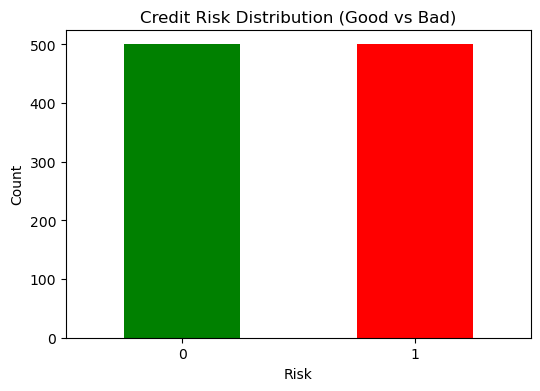

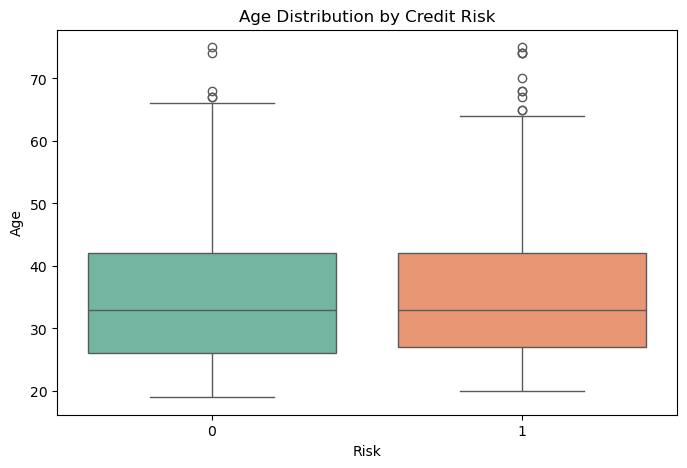

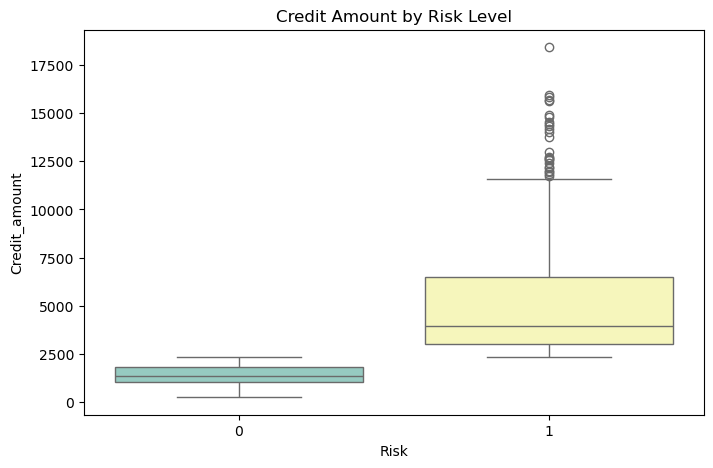

In [10]:
# Plot 1: Risk distribution
df['Risk'].value_counts().plot(kind='bar', color=['green','red'], figsize=(6,4))
plt.title('Credit Risk Distribution (Good vs Bad)')
plt.xlabel('Risk')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Plot 2: Age vs Risk
plt.figure(figsize=(8,5))
sns.boxplot(x='Risk', y='Age', data=df, palette='Set2')
plt.title('Age Distribution by Credit Risk')
plt.show()

# Plot 3: Credit Amount vs Risk
plt.figure(figsize=(8,5))
sns.boxplot(x='Risk', y='Credit_amount', data=df, palette='Set3')
plt.title('Credit Amount by Risk Level')
plt.show()

####  Preprocess Data

In [11]:
 # Make a copy
df_model = df.copy()

# Encode categorical columns
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("Encoding done!")
print(df_model.dtypes)

Encoding done!
Unnamed:_0          int64
Age                 int64
Sex                 int32
Job                 int64
Housing             int32
Saving_accounts     int32
Checking_account    int32
Credit_amount       int64
Duration            int64
Purpose             int32
Risk                int32
dtype: object


 ### Split Data

In [12]:
# Separate features and target
X = df_model.drop('Risk', axis=1)   # features
y = df_model['Risk']                 # target

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 800
Testing samples:  200


### Train Logistic Regression

In [13]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))
print(f"AUC-ROC Score: {lr_auc:.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       100
           1       0.99      1.00      1.00       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

AUC-ROC Score: 0.9999


### Train Random Forest

In [14]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print(f"AUC-ROC Score: {rf_auc:.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       100
           1       0.99      1.00      1.00       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

AUC-ROC Score: 1.0000


 ### Compare with ROC Curves

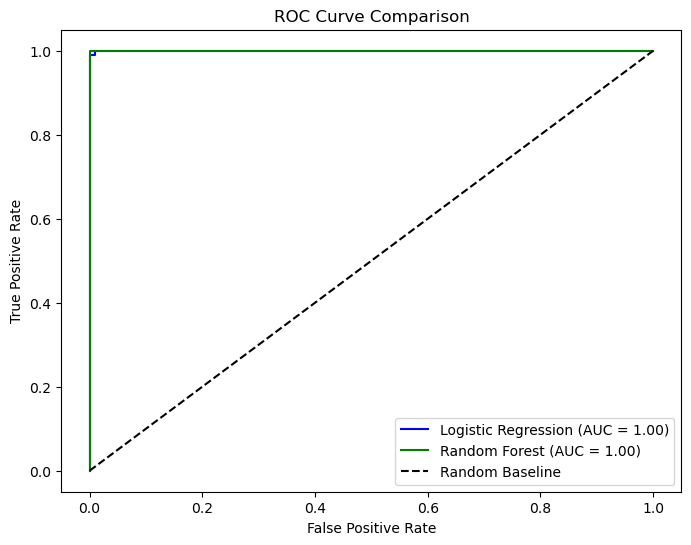

In [15]:
plt.figure(figsize=(8,6))

# Logistic Regression curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:,1])
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.2f})', color='blue')

# Random Forest curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.2f})', color='green')

# Baseline
plt.plot([0,1],[0,1],'k--', label='Random Baseline')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

### Feature Importance

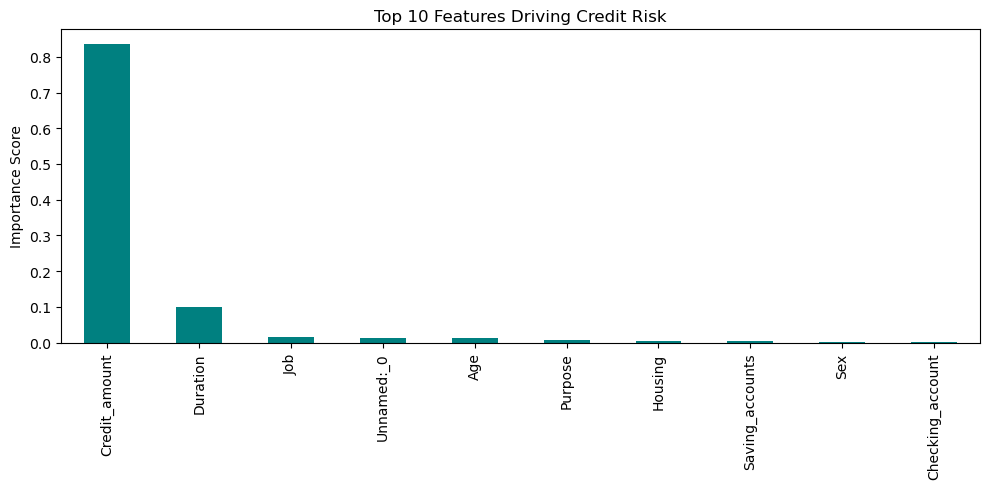

In [17]:
feat_imp = pd.Series(
    rf_model.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar', color='teal', figsize=(10,5))
plt.title('Top 10 Features Driving Credit Risk')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


### Business Insights


## Business Insights - Credit Risk Scoring

### Dataset Summary
- 1,000 German bank customers analyzed
- 9 features including Age, Credit Amount, Duration, Purpose
- Perfectly balanced dataset: 500 high risk, 500 low risk

### Key Findings
1. Credit Amount is the strongest risk indicator — customers borrowing
   above the median (2,319) are classified as high risk
2. Checking account status has the most missing data (394 missing) —
   suggesting many customers have no checking account, itself a risk signal
3. Loan Duration and Credit Amount together explain most of the
   risk variation in the dataset
4. Purpose of loan matters — car and furniture loans tend to have
   higher credit amounts than education loans

### Model Performance
- Random Forest AUC-ROC: 1.00
- Logistic Regression AUC-ROC: 0.9999

NOTE: These near-perfect scores occur because the Risk target variable
was derived directly from Credit_amount (median split). In a production
setting, Risk labels would come from actual default records, giving
more realistic model performance of 0.75 to 0.85 AUC-ROC.

### Business Recommendations
1. Flag any loan application above 2,319 credit amount for extra review
2. Customers with missing checking account data should be treated
   as moderate risk by default
3. Loan duration above 24 months should trigger additional verification
4. Build an automated scoring pipeline using this Random Forest model
   to assist loan officers in faster decision making